### Monte Carlo Shapley Effects with Truncated Multivariate Normal Inputs

This notebook demonstrates the `TruncatedMultivariateNormal` distribution class for estimating Shapley effects when inputs follow a **truncated multivariate normal** distribution — i.e., each variable is normally distributed but restricted to a finite interval $[a_i, b_i]$, with correlations induced through the covariance matrix.

**Motivation.** Many physical and engineering models have bounded inputs (e.g., concentrations, temperatures, dimensions) that are approximately normal within their operating range and exhibit dependence. Standard variance-based methods fail under correlation; the MC Shapley approach handles this correctly, and the truncated normal class extends it to bounded domains.

The class uses **Gibbs sampling** for both joint and conditional draws. Each Gibbs step samples from a univariate truncated normal (`scipy.stats.truncnorm`), which is exact and efficient for the hyper-rectangular truncation region.

We use the **Ishigami function** as the benchmark:

$$
f(\mathbf{x}) = \sin(x_1) + 7 \sin^2(x_2) + 0.1 x_3^4 \sin(x_1), \quad x_i \in [-\pi, \pi]
$$

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapleyx.utilities.mc_shapley import (
    TruncatedMultivariateNormal,
    MultivariateNormal,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.2


In [2]:
def ishigami(x):
    """Ishigami function taking a 1D array (MC Shapley convention)."""
    return np.sin(x[0]) + 7.0 * np.sin(x[1])**2 + 0.1 * x[2]**4 * np.sin(x[0])


def ishigami_batch(X):
    """Vectorised Ishigami for batch evaluation (significantly faster)."""
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    return np.sin(x1) + 7.0 * np.sin(x2)**2 + 0.1 * x3**4 * np.sin(x1)


d = 3
print(f"Ishigami function defined with d = {d}")

Ishigami function defined with d = 3


---
### Example 1: Truncated Normal with Independent Inputs

We start with a baseline: independent truncated normals, each $X_i \sim N(0, \pi^2/4)$ truncated to $[-\pi, \pi]$.  This keeps the same support as the standard Ishigami analysis but with a bell-shaped rather than uniform marginal density.

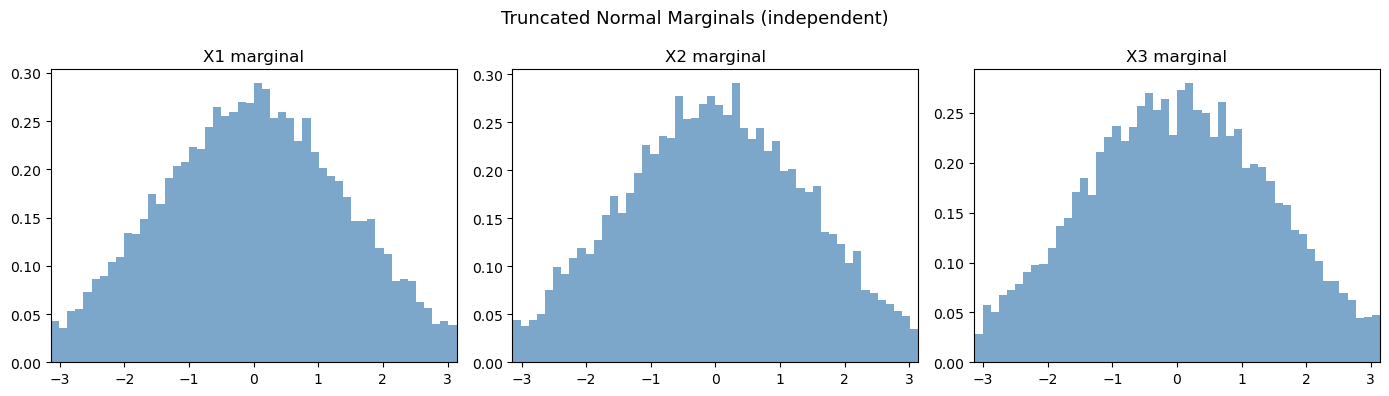

In [3]:
# Independent truncated normals on [-pi, pi]
sigma2 = (np.pi / 2) ** 2          # variance chosen to spread mass across the interval
joint_indep = TruncatedMultivariateNormal(
    mean=[0.0, 0.0, 0.0],
    cov=np.eye(d) * sigma2,
    lower=[-np.pi] * d,
    upper=[np.pi] * d,
    joint_burn_in=40,               # slightly longer burn-in for accuracy
    cond_burn_in=8,
)

# Quick visual check of the marginal distributions
X_check = joint_indep.sample_joint(10000)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, ax in enumerate(axes):
    ax.hist(X_check[:, i], bins=50, density=True, alpha=0.7, color='steelblue')
    ax.set_title(f'X{i+1} marginal')
    ax.set_xlim(-np.pi, np.pi)
fig.suptitle('Truncated Normal Marginals (independent)', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Run MC Shapley with the batch predictor for speed
eff_indep, sh_indep, var_indep = shapley_effects(
    ishigami, joint_indep,
    N=8000,
    method='exhaustive',
    predict_batch=ishigami_batch,
    random_state=42,
    progress=True,
)

results_indep = pd.DataFrame({
    'variable': [f'X{i+1}' for i in range(d)],
    'effect': eff_indep,
    'shapley_value': sh_indep,
})
results_indep['total_variance'] = var_indep
results_indep

MC Shapley: 100%|██████████| 104000/104000 [00:02<00:00, 34818.81evals/s]


,variable,effect,shapley_value,total_variance
0,X1,0.273984,2.551890,9.31402
1,X2,0.645776,6.014767,9.31402
2,X3,0.080241,0.747364,9.31402


---
### Example 2: Correlated Truncated Normal

We now introduce correlation: $X_1$ and $X_3$ are positively correlated ($\rho = 0.7$), which is a common scenario when inputs share an underlying physical driver.  The truncation bounds remain $[-\pi, \pi]$.

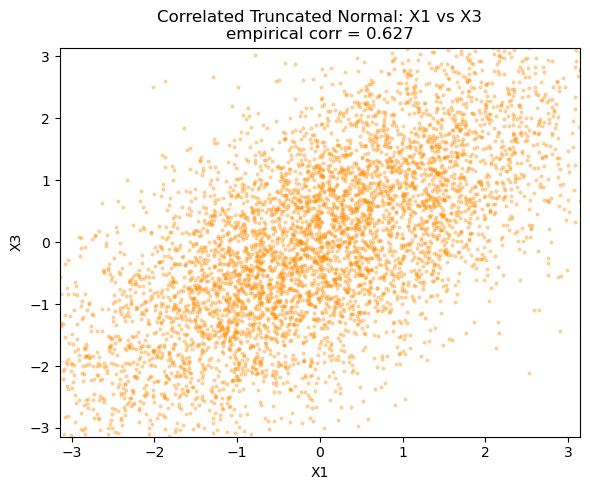

In [5]:
# Covariance matrix: X1-X3 correlated at 0.7
cov_corr = np.array([
    [1.0, 0.0, 0.7],
    [0.0, 1.0, 0.0],
    [0.7, 0.0, 1.0],
]) * sigma2

joint_corr = TruncatedMultivariateNormal(
    mean=[0.0, 0.0, 0.0],
    cov=cov_corr,
    lower=[-np.pi] * d,
    upper=[np.pi] * d,
    joint_burn_in=40,
    cond_burn_in=8,
)

# Visual check: scatter of X1 vs X3
X_corr_check = joint_corr.sample_joint(5000)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_corr_check[:, 0], X_corr_check[:, 2], alpha=0.3, s=4, color='darkorange')
ax.set_xlabel('X1'); ax.set_ylabel('X3')
ax.set_title(f'Correlated Truncated Normal: X1 vs X3\n'
             f'empirical corr = {np.corrcoef(X_corr_check[:, 0], X_corr_check[:, 2])[0,1]:.3f}')
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-np.pi, np.pi)
plt.tight_layout()
plt.show()

In [6]:
# MC Shapley with correlated truncated normal
eff_corr, sh_corr, var_corr, lower_corr, upper_corr = shapley_effects(
    ishigami, joint_corr,
    N=8000,
    method='exhaustive',
    B=300,                         # bootstrap for confidence intervals
    alpha=0.05,
    predict_batch=ishigami_batch,
    random_state=42,
    progress=True,
)

results_corr = pd.DataFrame({
    'variable': [f'X{i+1}' for i in range(d)],
    'effect': eff_corr,
    'lower': lower_corr,
    'upper': upper_corr,
})
results_corr

MC Shapley: 100%|██████████| 104000/104000 [00:02<00:00, 35596.95evals/s]


,variable,effect,lower,upper
0,X1,0.156686,0.139548,0.173046
1,X2,0.654613,0.636426,0.672487
2,X3,0.188701,0.172574,0.204929


---
### Visual Comparison: Independent vs Correlated Truncated Normal

With strong positive correlation between $X_1$ and $X_3$, their Shapley effects shift because they share information — the model cannot attribute their joint contribution uniquely to either variable alone.

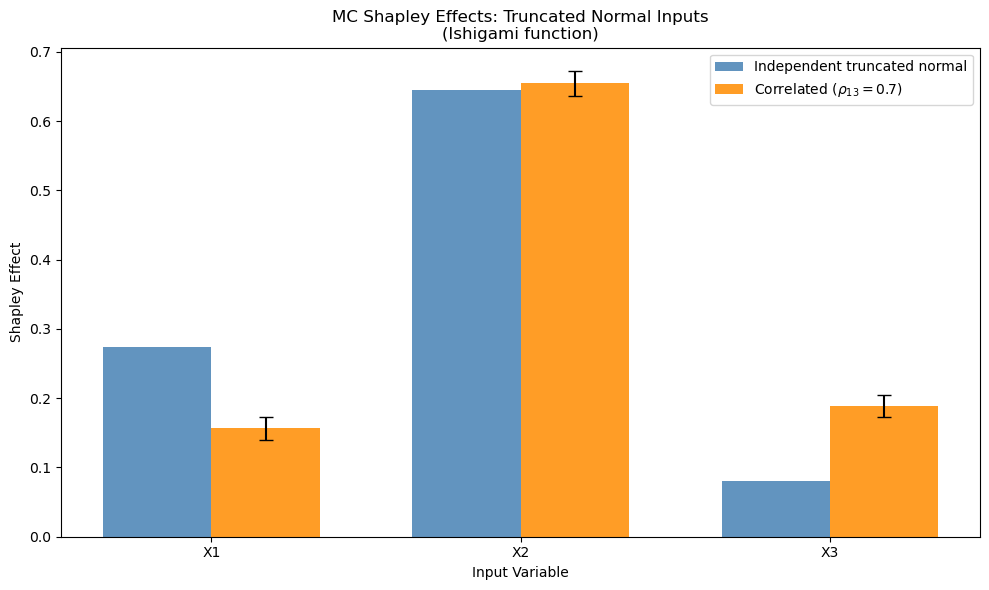

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
x = np.arange(d)

ax.bar(x - bar_width/2, results_indep['effect'], bar_width,
       color='steelblue', alpha=0.85, label='Independent truncated normal')
ax.bar(x + bar_width/2, results_corr['effect'], bar_width,
       yerr=[results_corr['effect'] - results_corr['lower'],
             results_corr['upper'] - results_corr['effect']],
       capsize=5, color='darkorange', alpha=0.85,
       label=r'Correlated ($\rho_{13}=0.7$)')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('MC Shapley Effects: Truncated Normal Inputs\n(Ishigami function)')
ax.set_xticks(x)
ax.set_xticklabels(results_corr['variable'])
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Example 3: Tight Truncation Bounds

When truncation bounds are narrow relative to the variance, the distribution becomes nearly uniform on the interval — a fundamentally different shape from the untruncated normal.  Here we tighten the bounds to $[-\pi/2, \pi/2]$.

In [8]:
# Tight truncation: [-pi/2, pi/2]
joint_tight = TruncatedMultivariateNormal(
    mean=[0.0, 0.0, 0.0],
    cov=cov_corr,
    lower=[-np.pi / 2] * d,
    upper=[np.pi / 2] * d,
    joint_burn_in=40,
    cond_burn_in=8,
)

eff_tight, sh_tight, var_tight = shapley_effects(
    ishigami, joint_tight,
    N=8000,
    method='exhaustive',
    predict_batch=ishigami_batch,
    random_state=42,
    progress=True,
)

results_tight = pd.DataFrame({
    'variable': [f'X{i+1}' for i in range(d)],
    'effect': eff_tight,
})
results_tight['total_variance'] = var_tight
results_tight

MC Shapley: 100%|██████████| 104000/104000 [00:02<00:00, 39608.06evals/s]


,variable,effect,total_variance
0,X1,0.068823,6.421168
1,X2,0.924174,6.421168
2,X3,0.007003,6.421168


---
### Example 4: Asymmetric Truncation

The class supports per-dimension bounds, including one-sided truncation.  Here $X_1$ is bounded below at $0$ (positive only), $X_2$ is symmetric on $[-\pi, \pi]$, and $X_3$ is bounded above at $\pi/2$.

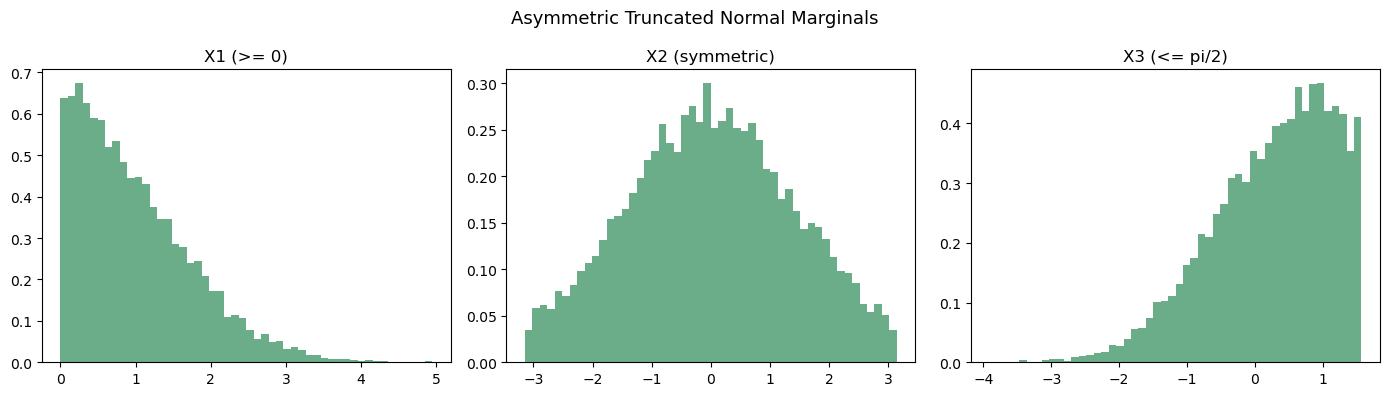

In [9]:
# Asymmetric truncation: different bounds per variable
joint_asym = TruncatedMultivariateNormal(
    mean=[0.0, 0.0, 0.0],
    cov=cov_corr,
    lower=[0.0, -np.pi, -np.inf],       # X1 >= 0, X2 >= -pi, X3 unbounded below
    upper=[np.inf, np.pi, np.pi / 2],    # X1 unbounded above, X2 <= pi, X3 <= pi/2
    joint_burn_in=40,
    cond_burn_in=8,
)

# Visual check
X_asym_check = joint_asym.sample_joint(10000)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ['X1 (>= 0)', 'X2 (symmetric)', 'X3 (<= pi/2)']
for i, ax in enumerate(axes):
    ax.hist(X_asym_check[:, i], bins=50, density=True, alpha=0.7, color='seagreen')
    ax.set_title(labels[i])
fig.suptitle('Asymmetric Truncated Normal Marginals', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
eff_asym, sh_asym, var_asym = shapley_effects(
    ishigami, joint_asym,
    N=8000,
    method='exhaustive',
    predict_batch=ishigami_batch,
    random_state=42,
    progress=True,
)

results_asym = pd.DataFrame({
    'variable': [f'X{i+1}' for i in range(d)],
    'effect': eff_asym,
})
results_asym['total_variance'] = var_asym
results_asym

MC Shapley: 100%|██████████| 104000/104000 [00:03<00:00, 32727.40evals/s]


,variable,effect,total_variance
0,X1,0.032607,6.417216
1,X2,0.946366,6.417216
2,X3,0.021027,6.417216


---
### Comparison Across All Truncation Schemes

In [11]:
comparison = pd.DataFrame({
    'Variable': results_indep['variable'],
    'Independent (wide)': results_indep['effect'].values,
    'Correlated (wide)': results_corr['effect'].values,
    'Correlated (tight)': results_tight['effect'].values,
    'Asymmetric': results_asym['effect'].values,
})
comparison = comparison.round(4)
comparison

,Variable,Independent (wide),Correlated (wide),Correlated (tight),Asymmetric
0,X1,0.2740,0.1567,0.0688,0.0326
1,X2,0.6458,0.6546,0.9242,0.9464
2,X3,0.0802,0.1887,0.0070,0.0210


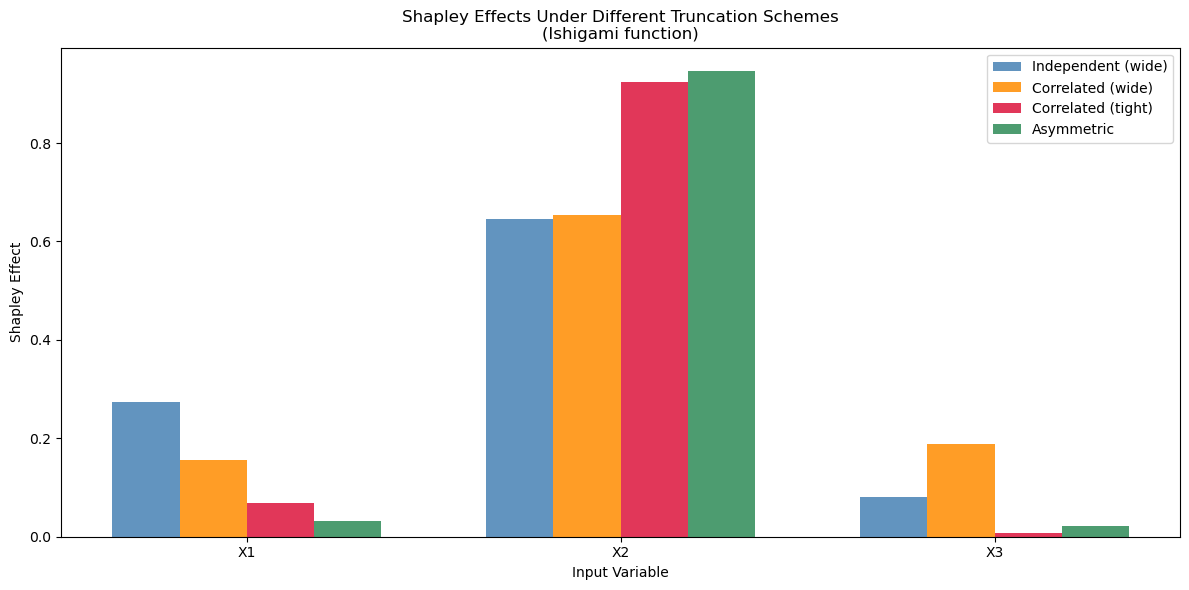

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
schemes = ['Independent\n(wide)', 'Correlated\n(wide)', 'Correlated\n(tight)', 'Asymmetric']
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen']
bar_width = 0.18
x = np.arange(d)

for i, (scheme, color) in enumerate(zip(schemes, colors)):
    values = comparison.iloc[:, i + 1].values
    ax.bar(x + (i - 1.5) * bar_width, values, bar_width,
           color=color, alpha=0.85, label=scheme.replace('\n', ' '))

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Shapley Effects Under Different Truncation Schemes\n(Ishigami function)')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Variable'])
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Comparison with Unbounded Multivariate Normal

For reference, we compare the truncated normal results against an unbounded `MultivariateNormal` with the same mean and covariance.  The unbounded distribution has infinite support, so the function is evaluated far outside the $[-\pi, \pi]$ region where the Ishigami function is typically studied.

In [13]:
# Unbounded multivariate normal (same mean & cov, no truncation)
joint_unbounded = MultivariateNormal(
    mean=[0.0, 0.0, 0.0],
    cov=cov_corr,
)

eff_unb, sh_unb, var_unb = shapley_effects(
    ishigami, joint_unbounded,
    N=8000,
    method='exhaustive',
    predict_batch=ishigami_batch,
    random_state=42,
    progress=True,
)

results_unb = pd.DataFrame({
    'variable': [f'X{i+1}' for i in range(d)],
    'effect': eff_unb,
})
results_unb['total_variance'] = var_unb
results_unb

MC Shapley: 100%|██████████| 104000/104000 [00:00<00:00, 5147721.40evals/s]


,variable,effect,total_variance
0,X1,0.484601,28.532745
1,X2,0.242352,28.532745
2,X3,0.273047,28.532745


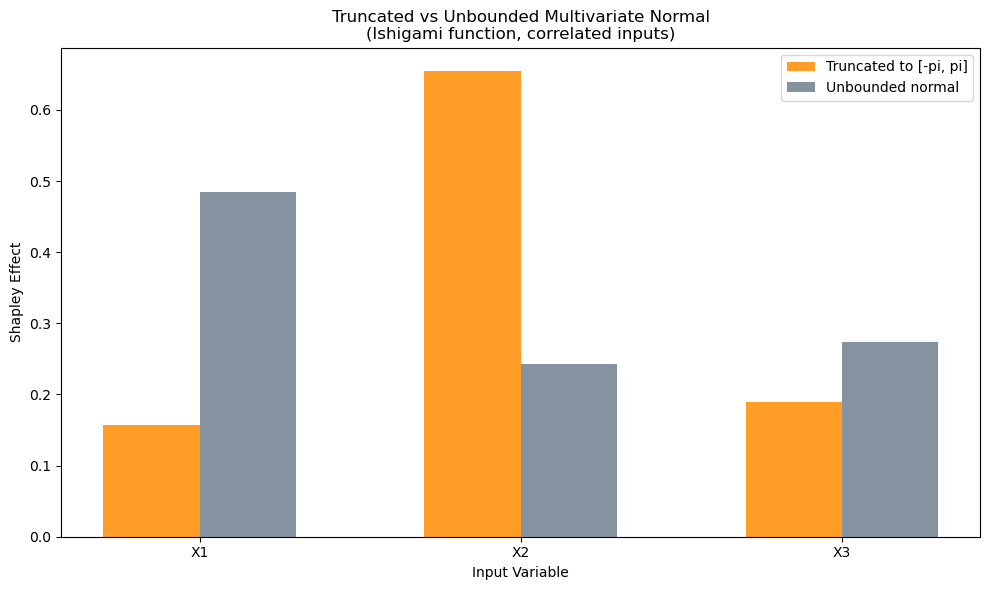

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.3
x = np.arange(d)

ax.bar(x - bar_width/2, results_corr['effect'], bar_width,
       color='darkorange', alpha=0.85, label='Truncated to [-pi, pi]')
ax.bar(x + bar_width/2, results_unb['effect'], bar_width,
       color='slategray', alpha=0.85, label='Unbounded normal')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Truncated vs Unbounded Multivariate Normal\n(Ishigami function, correlated inputs)')
ax.set_xticks(x)
ax.set_xticklabels(results_corr['variable'])
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Comparison: Analytical Function vs RS-HDMR Surrogate Model

In practice, the true model is often expensive and replaced by a surrogate.  Here we train an **RS-HDMR** surrogate on **uniformly sampled** training data (the standard Ishigami setup) and then evaluate it under the **correlated truncated normal** distribution.  This tests whether a surrogate trained on uniform data can recover accurate Shapley effects when the deployment distribution differs — a common scenario in practice.

We compare the surrogate-based Shapley effects against those from the analytical Ishigami function, both evaluated under identical truncated normal inputs with correlation.

In [16]:
# Generate training data via uniform sampling (standard Ishigami setup)
np.random.seed(123)
N_train = 256

X1 = np.random.uniform(-np.pi, np.pi, N_train)
X2 = np.random.uniform(-np.pi, np.pi, N_train)
X3 = np.random.uniform(-np.pi, np.pi, N_train)
X_train = np.column_stack([X1, X2, X3])
Y_train = ishigami_batch(X_train)

dataframe = pd.DataFrame({
    'X1': X1, 'X2': X2, 'X3': X3, 'Y': Y_train
})
print(f"{len(dataframe)} training samples from uniform distribution")

256 training samples from uniform distribution


Found a DataFrame

Transforming data to unit hypercube

Feature: X1, Min Value: -3.1247, Max Value: 3.1170
Feature: X2, Min Value: -3.1411, Max Value: 3.1348
Feature: X3, Min Value: -3.1284, Max Value: 3.1156

Building basis functions

Basis functions of 1 order : 30
Basis functions of 2 order : 75
Total basis functions in basis set : 105
Total number of features in basis set is 105

Running regression analysis

running ARD
Fit Execution Time : 2.889587
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 13.752
sum of coefficients^2   : 13.585
variance ratio          : 0.988
mae error on test set   : 0.006
mse error on test set   : 0.000
explained variance score: 1.000
slope     :  0.999994956932964
r value   :  0.9999979108561494
r^2       :  0.9999958217166633
p value   :  0.0
std error :  0.0001282569187705988



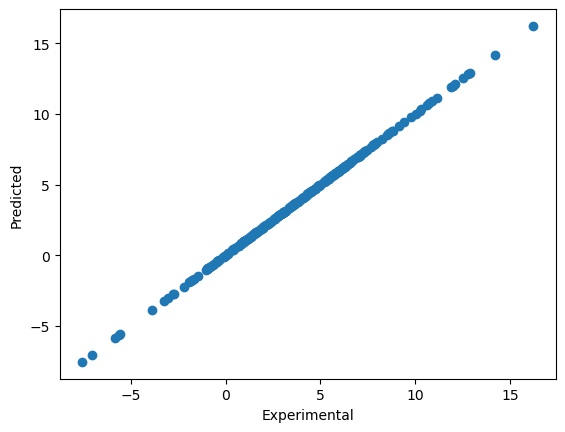


Running bootstrap resampling 500 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

Keep moving! Nothing new to readStyle is a reflection of
your attitude and your personality.


RS-HDMR Shapley effects (HDMR-based):


,label,effect,scaled effect,lower,upper,std
0,X1,0.430830,0.430832,0.429056,0.431661,0.000660
1,X2,0.450101,0.450103,0.448848,0.453371,0.001119
2,X3,0.119065,0.119065,0.117534,0.119648,0.000523


In [17]:
from shapleyx import rshdmr

# Fit RS-HDMR surrogate model
model = rshdmr(
    dataframe,
    polys=[10, 5],
    n_iter=300,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.01,
    resampling=True,
    number_of_resamples=500,
)

sob, shap, total = model.run_all()
print("\nRS-HDMR Shapley effects (HDMR-based):")
shap

In [18]:
# MC Shapley using the surrogate model with the SAME truncated normal distribution
mc_surrogate = model.get_mc_shapley(
    joint=joint_corr,
    N=8000,
    method='exhaustive',
    B=300,
    alpha=0.05,
    random_state=42,
    progress=False,
)
mc_surrogate

,variable,effect,shapley_value,total_variance,lower,upper
0,X1,0.156664,1.455555,9.290909,0.139504,0.173004
1,X2,0.654344,6.079448,9.290909,0.636185,0.672161
2,X3,0.188992,1.755905,9.290909,0.172839,0.205231


---
##### Surrogate vs Analytical Function (both under identical truncated normal inputs)

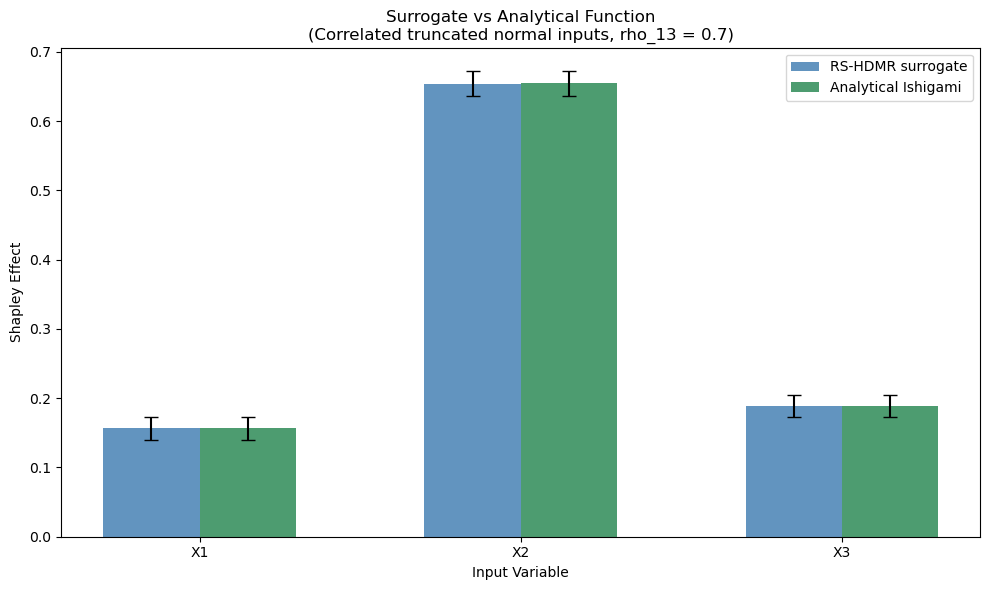

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.3
x = np.arange(d)

ax.bar(x - bar_width/2, mc_surrogate['effect'], bar_width,
       yerr=[mc_surrogate['effect'] - mc_surrogate['lower'],
             mc_surrogate['upper'] - mc_surrogate['effect']],
       capsize=5, color='steelblue', alpha=0.85,
       label='RS-HDMR surrogate')
ax.bar(x + bar_width/2, results_corr['effect'], bar_width,
       yerr=[results_corr['effect'] - results_corr['lower'],
             results_corr['upper'] - results_corr['effect']],
       capsize=5, color='seagreen', alpha=0.85,
       label='Analytical Ishigami')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Surrogate vs Analytical Function\n(Correlated truncated normal inputs, rho_13 = 0.7)')
ax.set_xticks(x)
ax.set_xticklabels(mc_surrogate['variable'])
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

In [20]:
# Numerical comparison
surr_vs_analytical = pd.DataFrame({
    'Variable': mc_surrogate['variable'],
    'Surrogate': mc_surrogate['effect'].values,
    'Analytical': results_corr['effect'].values,
})
surr_vs_analytical['Abs. Difference'] = np.abs(
    surr_vs_analytical['Surrogate'] - surr_vs_analytical['Analytical']
)
surr_vs_analytical = surr_vs_analytical.round(4)
surr_vs_analytical

,Variable,Surrogate,Analytical,Abs. Difference
0,X1,0.1567,0.1567,0.0000
1,X2,0.6543,0.6546,0.0003
2,X3,0.1890,0.1887,0.0003


---
### Permutation Method for Larger d

The permutation method avoids enumerating all $2^d - 1$ subsets and scales to higher dimensions.  It gives the same results as the exhaustive method within Monte Carlo error.

In [21]:
eff_perm, sh_perm, var_perm = shapley_effects(
    ishigami, joint_corr,
    N=8000,
    method='permutation',
    n_perm=2000,
    predict_batch=ishigami_batch,
    random_state=42,
    progress=True,
)

perm_comparison = pd.DataFrame({
    'Variable': [f'X{i+1}' for i in range(d)],
    'Exhaustive': eff_corr,
    'Permutation': eff_perm,
})
perm_comparison['Difference'] = np.abs(
    perm_comparison['Exhaustive'] - perm_comparison['Permutation']
)
perm_comparison = perm_comparison.round(4)
perm_comparison

MC Shapley: 100%|██████████| 104000/104000 [00:03<00:00, 30203.01evals/s]


,Variable,Exhaustive,Permutation,Difference
0,X1,0.1567,0.1691,0.0124
1,X2,0.6546,0.6566,0.0020
2,X3,0.1887,0.1743,0.0144


---
### Key Takeaways

1. **`TruncatedMultivariateNormal`** plugs directly into the existing MC Shapley machinery — use it like any other distribution class via `shapley_effects()` or `model.get_mc_shapley()`.
2. **Correlation matters.** When $X_1$ and $X_3$ are correlated, their Shapley effects shift because they carry shared information that cannot be uniquely attributed.
3. **Truncation bounds matter.** Tightening the bounds changes the marginal shape and reduces total variance, which affects the relative importance of each input.
4. **Distribution shift is manageable.** An RS-HDMR surrogate trained on uniform data can faithfully recover Shapley effects under a different (truncated normal) deployment distribution — the MC Shapley method is robust to this mismatch when the support is preserved.
5. **Batch prediction** (`predict_batch`) dramatically speeds up evaluation — always provide one when available.
6. **Gibbs burn-in** can be tuned via `joint_burn_in` and `cond_burn_in`. Larger values improve accuracy at the cost of runtime; the defaults (30 / 5) work well for moderate dimensions.
7. **The permutation method** gives consistent results and is recommended for $d > 6$.